# IE Pyrace - DQN - Performance Analysis

In [26]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
from scipy.ndimage import gaussian_filter1d

In [27]:
# Cell 2: Define plotting functions
def plot_rewards(rewards, window_size=100):
    """Plot the rewards over episodes with a moving average"""
    plt.figure(figsize=(15, 8))

    # Plot raw rewards
    plt.plot(rewards, alpha=0.3, color='blue', label='Raw Rewards')

    # Calculate and plot moving average
    moving_avg = pd.Series(rewards).rolling(window=window_size).mean()
    plt.plot(moving_avg, color='red', label=f'Moving Average ({window_size} episodes)')

    plt.title('Training Rewards over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_reward_distribution(rewards):
    """Plot the distribution of rewards"""
    plt.figure(figsize=(12, 8))
    plt.hist(rewards, bins=50, edgecolor='black')
    plt.title('Distribution of Rewards')
    plt.xlabel('Reward')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

def plot_learning_progress(rewards):
    """Plot various metrics to show learning progress"""
    plt.figure(figsize=(15, 8))

    # Plot best reward achieved so far
    best_so_far = np.maximum.accumulate(rewards)
    plt.plot(best_so_far, label='Best Reward Achieved')

    # Plot trend line
    z = np.polyfit(range(len(rewards)), rewards, 1)
    p = np.poly1d(z)
    plt.plot(p(range(len(rewards))), '--', label='Trend Line')

    plt.title('Learning Progress')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.legend()
    plt.grid(True)
    plt.show()

## Load and Visualize Training Data
First, let's load the rewards data from our training and create the visualizations.

In [28]:
# Cell 3: Load memory data
# Find the latest memory file
memory_files = glob.glob('models_DQN/memory_*_best.npy')
if not memory_files:
    raise FileNotFoundError("No memory_*_best.npy files found in models_DQN directory")

# Extract episode numbers and find the latest one
latest_memory_file = max(memory_files, key=lambda x: int(x.split('memory_')[1].split('_best.npy')[0]))
episode_number = int(latest_memory_file.split('memory_')[1].split('_best.npy')[0])
print(f"Loading memory from episode {episode_number}: {latest_memory_file}")

# Load and process the memory data
memory_data = np.load(latest_memory_file, allow_pickle=True)
print(f"Loaded memory data with shape: {memory_data.shape}")
print(f"Sample of first memory entry: {memory_data[0] if len(memory_data) > 0 else 'No data'}")

Loading memory from episode 443: models_DQN\memory_443_best.npy
Loaded memory data with shape: (10000, 5)
Sample of first memory entry: [array([3., 6., 7., 1., 1.], dtype=float32) 2 0
 array([3., 5., 9., 1., 1.], dtype=float32) False]


In [29]:
# Cell 4: Process memory data into episodes
# Process the memory data to extract rewards
total_rewards = []
current_episode_reward = 0
episode_steps = 0

print("\nProcessing memory entries...")
for i, entry in enumerate(memory_data):
    try:
        # Extract reward and done flag from numpy array
        reward = float(entry[2])  # Third element is the reward
        done = bool(entry[4])     # Fifth element is the done flag

        # Update current episode
        current_episode_reward += reward
        episode_steps += 1

        if done:
            print(f"Episode completed at step {i}. Total reward: {current_episode_reward:.2f}, Steps: {episode_steps}")
            total_rewards.append(current_episode_reward)
            current_episode_reward = 0
            episode_steps = 0

    except Exception as e:
        print(f"Error processing entry {i}: {str(e)}")
        print(f"Entry content: {entry}")

# Add the incomplete episode with -10000 reward if there's an ongoing episode
if current_episode_reward != 0:
    print(f"\nAdding incomplete episode with total reward: -10000")
    total_rewards.append(-10000)

rewards = np.array(total_rewards)
print(f"\nProcessed {len(rewards)} episodes from memory data")
print(f"Total memory entries processed: {len(memory_data)}")


Processing memory entries...
Episode completed at step 63. Total reward: -9108.50, Steps: 64
Episode completed at step 172. Total reward: -9133.50, Steps: 109
Episode completed at step 366. Total reward: -8663.00, Steps: 194
Episode completed at step 475. Total reward: -9124.00, Steps: 109
Episode completed at step 591. Total reward: -9106.00, Steps: 116
Episode completed at step 811. Total reward: -8620.50, Steps: 220
Episode completed at step 1273. Total reward: -7565.50, Steps: 462
Episode completed at step 1448. Total reward: -8638.50, Steps: 175
Episode completed at step 1627. Total reward: -8643.50, Steps: 179
Episode completed at step 1861. Total reward: -8220.50, Steps: 234
Episode completed at step 1971. Total reward: -9200.00, Steps: 110
Episode completed at step 2206. Total reward: -8262.00, Steps: 235
Episode completed at step 2449. Total reward: -8151.00, Steps: 243
Episode completed at step 2687. Total reward: -8236.50, Steps: 238
Episode completed at step 2861. Total re

In [30]:
# Cell 5: Basic Statistics
if len(rewards) == 0:
    print("\nWARNING: No episodes were completed!")
else:
    print("\nRewards statistics:")
    print(f"Number of episodes: {len(rewards)}")
    print(f"Number of complete episodes: {len(rewards[rewards != -10000])}")
    print(f"Number of incomplete episodes: {len(rewards[rewards == -10000])}")
    print(f"Average reward per complete episode: {np.mean(rewards[rewards != -10000]):.2f}")
    print(f"Max reward: {np.max(rewards):.2f}")
    print(f"Min reward: {np.min(rewards):.2f}")
    print(f"Standard Deviation: {np.std(rewards[rewards != -10000]):.2f}")


Rewards statistics:
Number of episodes: 39
Number of complete episodes: 39
Number of incomplete episodes: 0
Average reward per complete episode: -7970.41
Max reward: 10000.00
Min reward: -9200.00
Standard Deviation: 3009.06


Plotting rewards over time (including incomplete episodes)...


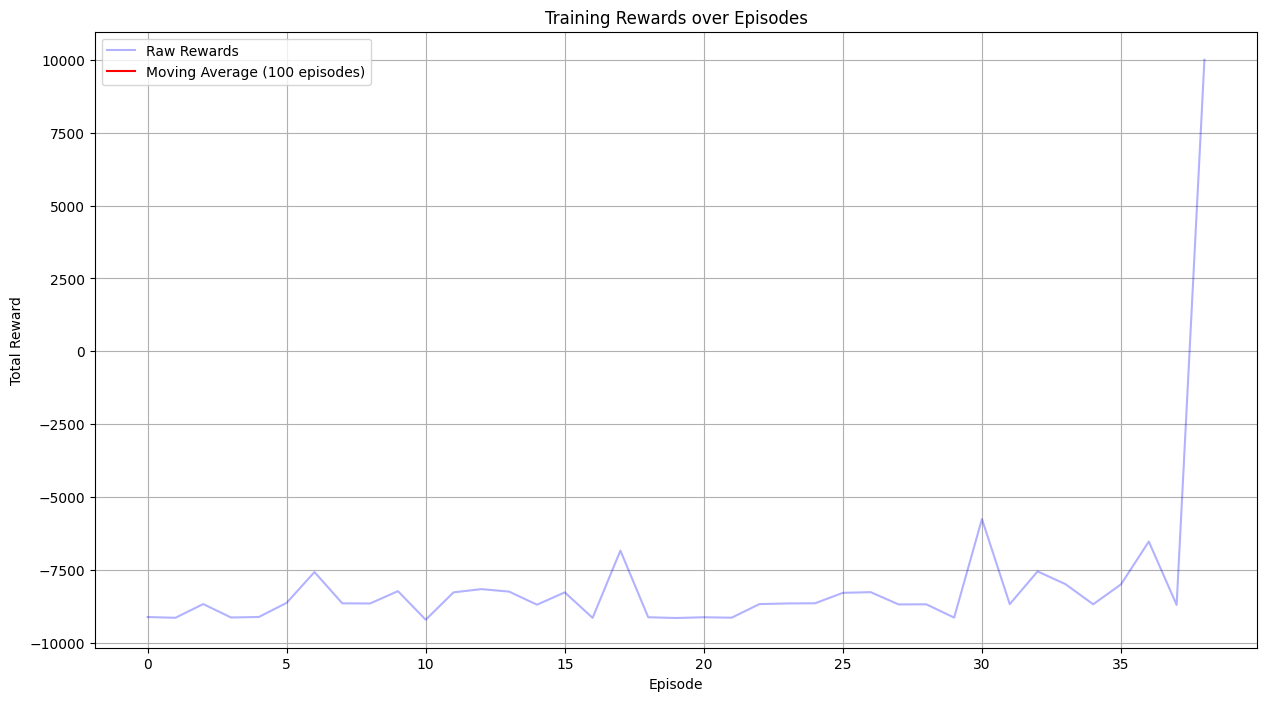


Plotting reward distribution (including incomplete episodes)...


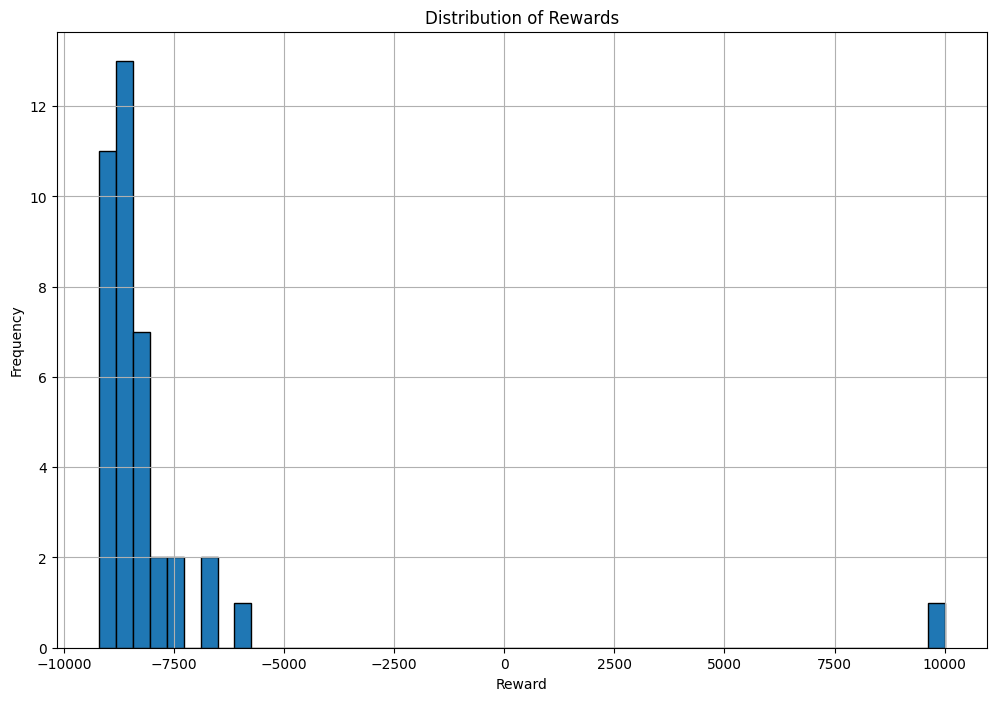


Plotting learning progress (including incomplete episodes)...


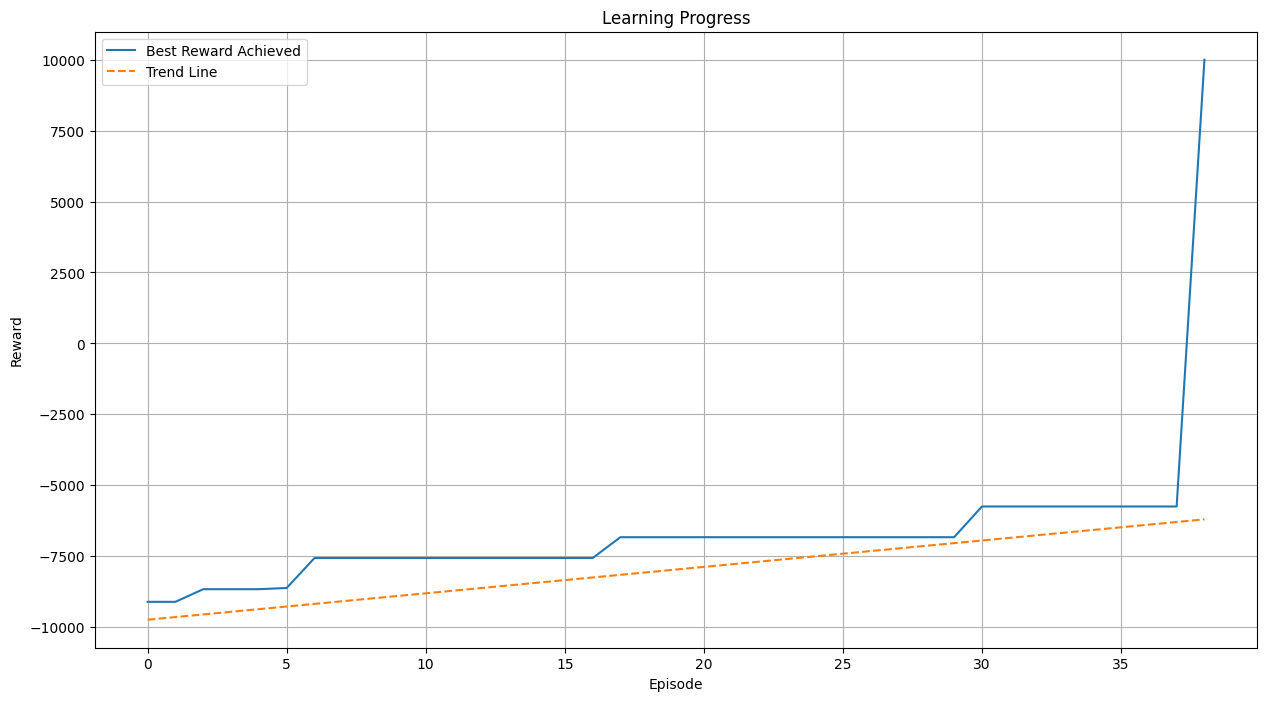

In [31]:
# Cell 6: Create Visualizations with ALL data
if len(rewards) > 0:
    print("Plotting rewards over time (including incomplete episodes)...")
    plot_rewards(rewards)

    print("\nPlotting reward distribution (including incomplete episodes)...")
    plot_reward_distribution(rewards)

    print("\nPlotting learning progress (including incomplete episodes)...")
    plot_learning_progress(rewards)